In [1]:
import scanpy as sc
import anndata as ad
import numpy as np
import pandas as pd
from scipy.io import mmread
import pickle

# Inital setting for plot size
from matplotlib import rcParams
FIGSIZE = (3, 3)
rcParams["figure.figsize"] = FIGSIZE

## preprocess data

In [2]:
# load data
matrix = mmread('../data/mouse_colon/orignal_data/matrix.mtx').tocsr()
genes = list(pd.read_csv('../data/mouse_colon/orignal_data/genes.tsv', header=None, index_col=None)[0])
barcodes = list(pd.read_csv('../data/mouse_colon/orignal_data/barcodes.tsv', header=None, index_col=None)[0])
tsne = pd.read_csv('../data/mouse_colon/orignal_data/tsne2.txt', skiprows=lambda x: x == 1, header=0, index_col=None, sep='\t')
neur_tsne = pd.read_csv('../data/mouse_colon/orignal_data/neur.tsne2.txt', skiprows=lambda x: x == 1, header=0, index_col=None, sep='\t')
glia_tsne = pd.read_csv('../data/mouse_colon/orignal_data/glia.tsne2.txt', skiprows=lambda x: x == 1, header=0, index_col=None, sep='\t')

# add cell type labels
adata = ad.AnnData(X=matrix.T)
adata.var.index = genes
adata.obs.index = barcodes
adata.obs['cell_type'] = list(tsne['LABEL'])
adata.obs.loc[neur_tsne['NAME'], 'cell_type'] = list(neur_tsne['LABEL'])
adata.obs.loc[glia_tsne['NAME'], 'cell_type'] = list(glia_tsne['LABEL'])
adata.obsm['tsne'] = np.array(tsne.loc[:, ['X', 'Y']]).astype(np.float32)

# add metadata
meta_df = pd.read_csv('../data/mouse_colon/orignal_data/all.meta.txt', skiprows=lambda x: x == 1, header=0, index_col=None, sep='\t')
cell2sex = dict(zip(meta_df['NAME'], meta_df['Sex']))
cell2uniqid = dict(zip(meta_df['NAME'], meta_df['Unique_ID']))
cell2mouseid = dict(zip(meta_df['NAME'], meta_df['Mouse_ID']))
adata.obs['Sex'] = [cell2sex[cell] for cell in adata.obs_names]
adata.obs['Unique_ID'] = [cell2uniqid[cell] for cell in adata.obs_names]
adata.obs['Mouse_ID'] = [cell2mouseid[cell] for cell in adata.obs_names]

/tmp/ipykernel_2729225/519126681.py:19: DtypeWarning: Columns (1,4,5,7,9,11,12) have mixed types. Specify dtype option on import or set low_memory=False.
  meta_df = pd.read_csv('../data/mouse_colon/orignal_data/all.meta.txt', skiprows=lambda x: x == 1, header=0, index_col=None, sep='\t')


In [3]:
adata.shape

(343000, 24157)

In [4]:
# check number of count and genes per cell
adata.obs['n_counts'] = np.sum(adata.X, axis=1)
adata.obs['n_genes'] = np.sum(adata.X > 0, axis=1)
adata.var['n_cells'] = np.asarray(np.sum(adata.X > 0, axis=0)).ravel()
print(adata.obs['n_counts'].min())
print(adata.obs['n_genes'].min())
print(adata.var['n_cells'].min())

1174
999
3


## filter low exp genes

In [5]:
sc.pp.filter_genes(adata, min_cells=10)
adata.shape

(343000, 23245)

## rename cell types

/mnt/ufs18/rs-032/FishEvoDevoGeno/Hao/icepop_analysis/.venv/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


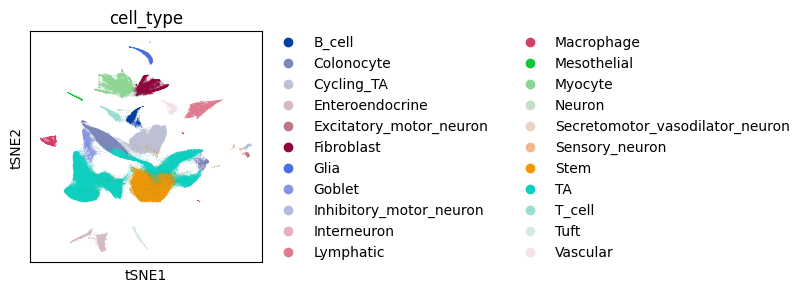

In [6]:
# rename cell types and combine subtypes
adata.obs['cell_type'] = adata.obs['cell_type'].str.replace(r'_\d+$', '', regex=True)
cellname_map = {
    'PEMN': 'Excitatory_motor_neuron',
    'PIMN': 'Inhibitory_motor_neuron',
    'PIN': 'Interneuron',
    'PSVN': 'Secretomotor_vasodilator_neuron',
    'PSN': 'Sensory_neuron',
}
adata.obs['cell_type'] = [cellname_map[ct] if ct in cellname_map else ct for ct in adata.obs['cell_type']]

sc.pl.tsne(adata, color='cell_type')

## convert symbol to entrez

In [9]:
with open('../data/mouse_name2id.pkl', 'rb') as f:
    gene2id = pickle.load(f)

converted = []
for gene in adata.var_names:
    if gene in gene2id:
        ids = gene2id[gene]
        if len(ids) == 1:
            converted.append(ids[0])
        else:
            converted.append(None)
    else:
        converted.append(None)
adata.var['entrez'] = converted
adata = adata[:, ~pd.isna(adata.var['entrez'])]

In [10]:
# keep genes with max expression across cells
var_df = adata.var.copy()
var_df['mean_exp'] = np.array(np.mean(adata.X, axis=0))[0][:, None]
var_df = var_df.sort_values(by='mean_exp', ascending=False)
sym_to_keep = list(var_df[~var_df['entrez'].duplicated()].index)
adata = adata[:, adata.var.index.isin(sym_to_keep)].copy()

In [11]:
# repalce index
adata.var['symbol'] = adata.var_names
adata.var_names = adata.var['entrez']
del adata.var['entrez']

In [12]:
adata.shape

(343000, 21349)

In [13]:
adata.X = adata.X.astype(np.float32)

## save

In [14]:
adata.write('../data/mouse_colon/mouse_colon_cnt.h5ad')